## 인공지능 8주차

In [58]:
class Encoder:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn
        
        embed_W = (rn(V,D) / 100)

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [60]:
df = pd.read_csv("ASOS_mean_temp.csv", encoding = 'cp949')

In [61]:
df["일시"] = pd.to_datetime(df["일시"])
summer = df[df["일시"].dt.month.isin([6, 7, 8])]

print(summer)

summer.isnull().sum()

       지점 지점명         일시  평균기온(°C)
151   108  서울 2006-06-01      22.7
152   108  서울 2006-06-02      25.9
153   108  서울 2006-06-03      23.4
154   108  서울 2006-06-04      20.8
155   108  서울 2006-06-05      21.3
...   ...  ..        ...       ...
7178  108  서울 2025-08-27      26.7
7179  108  서울 2025-08-28      28.3
7180  108  서울 2025-08-29      29.0
7181  108  서울 2025-08-30      28.4
7182  108  서울 2025-08-31      28.5

[1840 rows x 4 columns]


지점          0
지점명         0
일시          0
평균기온(°C)    0
dtype: int64

2006년부터 2025년도까지 시계열을 각 년도별로 slicing

In [62]:
train = df[df['일시'] < '2022-01-01'].copy()

val = df[(df['일시'] >= '2022-01-01') & (df['일시'] < '2024-01-01')].copy()

test = df[df['일시'] >= '2024-01-01'].copy()


In [ ]:
# 표준화
temp_col = '평균기온(°C)'

train_mean = train[temp_col].mean()
train_std = train[temp_col].std()

train['temp_scaled'] = (train[temp_col] - train_mean) / train_std
val['temp_scaled']   = (val[temp_col] - train_mean) / train_std
test['temp_scaled']  = (test[temp_col] - train_mean) / train_std

print('평균:', train_mean)
print('표준편차:', train_std)

평균: 13.039425051334701
표준편차: 10.575252098725377


In [64]:

def make_sequences(data, window_size=7):
    X = []
    y = []

    values = data['temp_scaled'].values

    for i in range(len(values) - window_size):
        X.append(values[i:i + window_size])
        y.append(values[i + window_size])

    X = np.array(X)
    y = np.array(y)

    # (데이터 수, time_size, input_size)
    X = X.reshape(-1, window_size, 1)

    return X, y

window_size = 7

X_train, y_train = make_sequences(train, window_size)
X_val, y_val = make_sequences(val, window_size)
X_test, y_test = make_sequences(test, window_size)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(5837, 7, 1) (5837,)
(723, 7, 1) (723,)
(724, 7, 1) (724,)


---
## Week7의 LSTM으로 다음 날 평균기온 예측

7일간의 정규화된 평균기온을 `TimeLSTM`에 입력하고, 마지막 은닉 상태로 다음 날 평균기온을 예측한다. 손실 함수는 회귀 문제에 맞게 평균제곱오차(MSE)를 사용한다.

In [65]:
# Week7에서 구현한 LSTM과 TimeLSTM을 연속값 입력에 사용
def sigmoid(x):
    x = np.clip(x, -50, 50)
    return 1 / (1 + np.exp(-x))


class LSTM:
    def __init__(self, Wx, Wh, b):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.cache = None

    def forward(self, x, h_prev, c_prev):
        Wx, Wh, b = self.params
        H = h_prev.shape[1]
        A = np.dot(x, Wx) + np.dot(h_prev, Wh) + b

        f = sigmoid(A[:, :H])
        g = np.tanh(A[:, H:2 * H])
        i = sigmoid(A[:, 2 * H:3 * H])
        o = sigmoid(A[:, 3 * H:])

        c_next = f * c_prev + g * i
        h_next = o * np.tanh(c_next)
        self.cache = (x, h_prev, c_prev, i, f, g, o, c_next)
        return h_next, c_next

    def backward(self, dh_next, dc_next):
        Wx, Wh, b = self.params
        x, h_prev, c_prev, i, f, g, o, c_next = self.cache

        tanh_c = np.tanh(c_next)
        ds = dc_next + dh_next * o * (1 - tanh_c ** 2)
        dc_prev = ds * f

        di = ds * g * i * (1 - i)
        df = ds * c_prev * f * (1 - f)
        do = dh_next * tanh_c * o * (1 - o)
        dg = ds * i * (1 - g ** 2)
        dA = np.hstack((df, dg, di, do))

        self.grads[0][...] = np.dot(x.T, dA)
        self.grads[1][...] = np.dot(h_prev.T, dA)
        self.grads[2][...] = dA.sum(axis=0)

        dx = np.dot(dA, Wx.T)
        dh_prev = np.dot(dA, Wh.T)
        return dx, dh_prev, dc_prev


class TimeLSTM:
    def __init__(self, Wx, Wh, b):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.layers = None

    def forward(self, xs):
        Wx, Wh, b = self.params
        N, T, _ = xs.shape
        H = Wh.shape[0]
        h = np.zeros((N, H), dtype=np.float32)
        c = np.zeros((N, H), dtype=np.float32)
        hs = np.empty((N, T, H), dtype=np.float32)
        self.layers = []

        for t in range(T):
            layer = LSTM(*self.params)
            h, c = layer.forward(xs[:, t, :], h, c)
            hs[:, t, :] = h
            self.layers.append(layer)
        return hs

    def backward(self, dhs):
        Wx, Wh, b = self.params
        N, T, H = dhs.shape
        D = Wx.shape[0]
        dxs = np.empty((N, T, D), dtype=np.float32)
        dh = np.zeros((N, H), dtype=np.float32)
        dc = np.zeros((N, H), dtype=np.float32)
        grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]

        for t in reversed(range(T)):
            layer = self.layers[t]
            dx, dh, dc = layer.backward(dhs[:, t, :] + dh, dc)
            dxs[:, t, :] = dx
            for i, grad in enumerate(layer.grads):
                grads[i] += grad

        for i, grad in enumerate(grads):
            self.grads[i][...] = grad
        return dxs

In [ ]:
class WeatherLSTM:
    def __init__(self, input_size=1, hidden_size=32):
        D, H = input_size, hidden_size
        rn = np.random.randn
        lstm_Wx = (rn(D, 4 * H) / np.sqrt(D)).astype('f')
        lstm_Wh = (rn(H, 4 * H) / np.sqrt(H)).astype('f')
        lstm_b = np.zeros(4 * H, dtype='f')
        # output_W: h 합치는 가중치
        output_W = (rn(H, 1) / np.sqrt(H)).astype('f')
        output_b = np.zeros(1, dtype='f')

        self.lstm = TimeLSTM(lstm_Wx, lstm_Wh, lstm_b)
        self.output_params = [output_W, output_b]
        self.output_grads = [np.zeros_like(output_W), np.zeros_like(output_b)]
        
        # lstm.params + output_params: 두 리스트를 하나로 연결(덧셈 연산 아님)
        self.params = self.lstm.params + self.output_params
        self.grads = self.lstm.grads + self.output_grads
        self.hs = None
        self.pred = None
        self.target = None

    def predict(self, xs):
        self.hs = self.lstm.forward(xs)
        W, b = self.output_params
        self.pred = (np.dot(self.hs[:, -1, :], W) + b).reshape(-1)
        return self.pred

    def forward(self, xs, target):
        pred = self.predict(xs)
        self.target = target.reshape(-1)
        return np.mean((pred - self.target) ** 2) # return MSE

    def backward(self):
        N = len(self.target)
        dpred = (2.0 / N) * (self.pred - self.target) # dL/dpred: MSE 미분
        dout = dpred.reshape(-1, 1) # 출력 계산 위해 shape 변경
        W, _ = self.output_params

        self.output_grads[0][...] = np.dot(self.hs[:, -1, :].T, dout)
        self.output_grads[1][...] = dout.sum(axis=0) # 편향의 기울기 계산

        dhs = np.zeros_like(self.hs)
        dhs[:, -1, :] = np.dot(dout, W.T)
        return self.lstm.backward(dhs)


def clip_grads(grads, max_norm=5.0):
    total_norm = np.sqrt(sum(float(np.sum(grad ** 2)) for grad in grads))
    rate = max_norm / (total_norm + 1e-7)
    if rate < 1:
        for grad in grads:
            grad *= rate


class Adam:
    def __init__(self, lr=0.003, beta1=0.9, beta2=0.999):
        self.lr, self.beta1, self.beta2 = lr, beta1, beta2
        self.iter = 0
        self.m, self.v = None, None

    def update(self, params, grads):
        if self.m is None:
            self.m = [np.zeros_like(param) for param in params]
            self.v = [np.zeros_like(param) for param in params]

        self.iter += 1
        lr_t = self.lr * np.sqrt(1 - self.beta2 ** self.iter) / (1 - self.beta1 ** self.iter)
        for i, (param, grad) in enumerate(zip(params, grads)):
            self.m[i] += (1 - self.beta1) * (grad - self.m[i])
            self.v[i] += (1 - self.beta2) * (grad ** 2 - self.v[i])
            param -= lr_t * self.m[i] / (np.sqrt(self.v[i]) + 1e-7)

In [ ]:
# 평균 손실 계산 함수
def evaluate_loss(model, X, y, batch_size=256):
    total_loss = 0.0
    for start in range(0, len(X), batch_size):
        end = min(start + batch_size, len(X))
        loss = model.forward(X[start:end], y[start:end])
        total_loss += loss * (end - start)
    return total_loss / len(X)


X_train_f = X_train.astype('f')
y_train_f = y_train.astype('f')
X_val_f = X_val.astype('f')
y_val_f = y_val.astype('f')
X_test_f = X_test.astype('f')

np.random.seed(42)
model = WeatherLSTM(input_size=X_train_f.shape[2], hidden_size=32)
optimizer = Adam(lr=0.003)
rng = np.random.default_rng(42)
batch_size = 64
max_epoch = 80
patience = 10
best_val_loss = np.inf
best_params = None
wait = 0
train_loss_history = []
val_loss_history = []

for epoch in range(1, max_epoch + 1):
    indices = rng.permutation(len(X_train_f))
    total_loss = 0.0

    for start in range(0, len(indices), batch_size):
        batch_idx = indices[start:start + batch_size]
        batch_x = X_train_f[batch_idx]
        batch_y = y_train_f[batch_idx]

        loss = model.forward(batch_x, batch_y)
        model.backward()
        clip_grads(model.grads, max_norm=5.0)
        optimizer.update(model.params, model.grads)
        total_loss += loss * len(batch_idx)

    train_loss = total_loss / len(X_train_f)
    val_loss = evaluate_loss(model, X_val_f, y_val_f)
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        best_params = [param.copy() for param in model.params]
        wait = 0
    else:
        wait += 1

    if epoch == 1 or epoch % 5 == 0:
        print(f'epoch {epoch:3d} | train MSE {train_loss:.4f} | val MSE {val_loss:.4f}')

    if wait >= patience:
        print(f'Early stopping: epoch {epoch}, best val MSE {best_val_loss:.4f}')
        break

# 검증 손실이 가장 낮았던 시점의 가중치를 복원한다.
for param, best_param in zip(model.params, best_params):
    param[...] = best_param

epoch   1 | train MSE 0.2396 | val MSE 0.0766
epoch   5 | train MSE 0.0462 | val MSE 0.0474
epoch  10 | train MSE 0.0458 | val MSE 0.0473
epoch  15 | train MSE 0.0456 | val MSE 0.0468
epoch  20 | train MSE 0.0454 | val MSE 0.0472
Early stopping: epoch 22, best val MSE 0.0467


LSTM test MAE  : 1.689 °C
LSTM test RMSE : 2.210 °C
Naive test MAE : 1.807 °C
Naive test RMSE: 2.411 °C


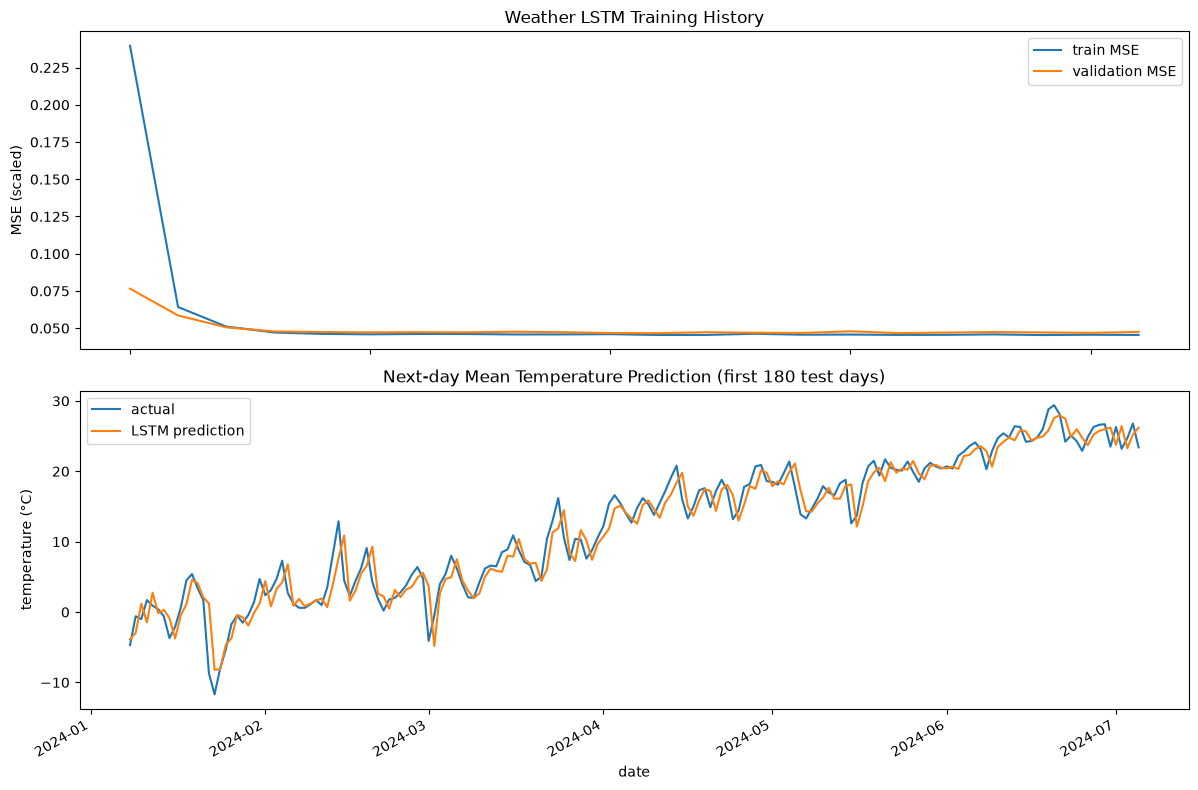

In [68]:
def predict_in_batches(model, X, batch_size=256):
    predictions = []
    for start in range(0, len(X), batch_size):
        predictions.append(model.predict(X[start:start + batch_size]).copy())
    return np.concatenate(predictions)


# 정규화 값을 다시 섭씨온도로 복원한다.
pred_scaled = predict_in_batches(model, X_test_f)
pred_temp = pred_scaled * train_std + train_mean
actual_temp = y_test * train_std + train_mean
naive_temp = X_test[:, -1, 0] * train_std + train_mean  # 어제 기온을 그대로 예측한 기준선

mae = np.mean(np.abs(pred_temp - actual_temp))
rmse = np.sqrt(np.mean((pred_temp - actual_temp) ** 2))
naive_mae = np.mean(np.abs(naive_temp - actual_temp))
naive_rmse = np.sqrt(np.mean((naive_temp - actual_temp) ** 2))

print(f'LSTM test MAE  : {mae:.3f} °C')
print(f'LSTM test RMSE : {rmse:.3f} °C')
print(f'Naive test MAE : {naive_mae:.3f} °C')
print(f'Naive test RMSE: {naive_rmse:.3f} °C')

test_dates = test['일시'].iloc[window_size:].to_numpy()
show_days = min(180, len(test_dates))

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(train_loss_history, label='train MSE')
axes[0].plot(val_loss_history, label='validation MSE')
axes[0].set_title('Weather LSTM Training History')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('MSE (scaled)')
axes[0].legend()

axes[1].plot(test_dates[:show_days], actual_temp[:show_days], label='actual')
axes[1].plot(test_dates[:show_days], pred_temp[:show_days], label='LSTM prediction')
axes[1].set_title('Next-day Mean Temperature Prediction (first 180 test days)')
axes[1].set_xlabel('date')
axes[1].set_ylabel('temperature (°C)')
axes[1].legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

---
## 최근 14일 기온으로 다음 주 7일 예측

최근 14일의 평균기온과 날짜 계절 정보(`sin`, `cos`)를 입력하고 다음 7일을 동시에 출력한다. 예측값을 다시 입력하는 재귀 방식이 아니므로 일주일 안에서의 연쇄적인 오차 누적을 줄일 수 있다.

In [69]:
def make_week_sequences(data, input_days=14, forecast_days=7):
    temps = data['temp_scaled'].to_numpy(dtype=np.float32)
    day_of_year = data['일시'].dt.dayofyear.to_numpy()

    # 12월 31일과 1월 1일이 가깝다는 것을 모델에 알려주는 순환형 날짜 특성
    day_sin = np.sin(2 * np.pi * day_of_year / 365.25)
    day_cos = np.cos(2 * np.pi * day_of_year / 365.25)
    features = np.column_stack((temps, day_sin, day_cos)).astype('f')

    X, y = [], []
    last_start = len(data) - input_days - forecast_days + 1
    for start in range(last_start):
        X.append(features[start:start + input_days])
        target_start = start + input_days
        y.append(temps[target_start:target_start + forecast_days])

    return np.asarray(X, dtype='f'), np.asarray(y, dtype='f')


input_days = 14
forecast_days = 7
Xw_train, yw_train = make_week_sequences(train, input_days, forecast_days)
Xw_val, yw_val = make_week_sequences(val, input_days, forecast_days)
Xw_test, yw_test = make_week_sequences(test, input_days, forecast_days)

print('train:', Xw_train.shape, yw_train.shape)
print('val  :', Xw_val.shape, yw_val.shape)
print('test :', Xw_test.shape, yw_test.shape)

train: (5824, 14, 3) (5824, 7)
val  : (710, 14, 3) (710, 7)
test : (711, 14, 3) (711, 7)


In [70]:
class WeatherWeekLSTM:
    def __init__(self, input_size=3, hidden_size=48, forecast_days=7, input_days=14):
        D, H, F = input_size, hidden_size, forecast_days
        rn = np.random.randn
        lstm_Wx = (rn(D, 4 * H) / np.sqrt(D)).astype('f')
        lstm_Wh = (rn(H, 4 * H) / np.sqrt(H)).astype('f')
        lstm_b = np.zeros(4 * H, dtype='f')
        output_W = (rn(H, F) / np.sqrt(H)).astype('f')
        output_b = np.zeros(F, dtype='f')

        self.input_days = input_days
        self.forecast_days = forecast_days
        self.lstm = TimeLSTM(lstm_Wx, lstm_Wh, lstm_b)
        self.output_params = [output_W, output_b]
        self.output_grads = [np.zeros_like(output_W), np.zeros_like(output_b)]
        self.params = self.lstm.params + self.output_params
        self.grads = self.lstm.grads + self.output_grads
        self.hs = None
        self.pred = None
        self.target = None

    def predict(self, xs):
        self.hs = self.lstm.forward(xs)
        W, b = self.output_params
        self.pred = np.dot(self.hs[:, -1, :], W) + b
        return self.pred

    def forward(self, xs, target):
        pred = self.predict(xs)
        self.target = target
        return np.mean((pred - target) ** 2)

    def backward(self):
        diff = self.pred - self.target
        dout = (2.0 / diff.size) * diff
        W, _ = self.output_params

        self.output_grads[0][...] = np.dot(self.hs[:, -1, :].T, dout)
        self.output_grads[1][...] = dout.sum(axis=0)

        dhs = np.zeros_like(self.hs)
        dhs[:, -1, :] = np.dot(dout, W.T)
        return self.lstm.backward(dhs)

In [71]:
np.random.seed(42)
week_model = WeatherWeekLSTM(
    input_size=Xw_train.shape[2],
    hidden_size=48,
    forecast_days=forecast_days,
    input_days=input_days
)
week_optimizer = Adam(lr=0.003)
week_rng = np.random.default_rng(42)
week_batch_size = 64
week_max_epoch = 80
week_patience = 10
week_best_val_loss = np.inf
week_best_params = None
week_wait = 0
week_train_history = []
week_val_history = []

for epoch in range(1, week_max_epoch + 1):
    indices = week_rng.permutation(len(Xw_train))
    total_loss = 0.0

    for start in range(0, len(indices), week_batch_size):
        batch_idx = indices[start:start + week_batch_size]
        loss = week_model.forward(Xw_train[batch_idx], yw_train[batch_idx])
        week_model.backward()
        clip_grads(week_model.grads, max_norm=5.0)
        week_optimizer.update(week_model.params, week_model.grads)
        total_loss += loss * len(batch_idx)

    train_loss = total_loss / len(Xw_train)
    val_loss = evaluate_loss(week_model, Xw_val, yw_val)
    week_train_history.append(train_loss)
    week_val_history.append(val_loss)

    if val_loss < week_best_val_loss - 1e-6:
        week_best_val_loss = val_loss
        week_best_params = [param.copy() for param in week_model.params]
        week_wait = 0
    else:
        week_wait += 1

    if epoch == 1 or epoch % 5 == 0:
        print(f'epoch {epoch:3d} | train MSE {train_loss:.4f} | val MSE {val_loss:.4f}')

    if week_wait >= week_patience:
        print(f'Early stopping: epoch {epoch}, best val MSE {week_best_val_loss:.4f}')
        break

for param, best_param in zip(week_model.params, week_best_params):
    param[...] = best_param

epoch   1 | train MSE 0.1729 | val MSE 0.1048
epoch   5 | train MSE 0.0816 | val MSE 0.0976
epoch  10 | train MSE 0.0803 | val MSE 0.0951
epoch  15 | train MSE 0.0790 | val MSE 0.0971
epoch  20 | train MSE 0.0780 | val MSE 0.1017
Early stopping: epoch 20, best val MSE 0.0951


7-day LSTM MAE : 2.426 °C
7-day LSTM RMSE: 3.109 °C
7-day Naive MAE: 2.985 °C
1일 후 MAE: 1.682 °C
2일 후 MAE: 2.292 °C
3일 후 MAE: 2.476 °C
4일 후 MAE: 2.599 °C
5일 후 MAE: 2.659 °C
6일 후 MAE: 2.635 °C
7일 후 MAE: 2.638 °C


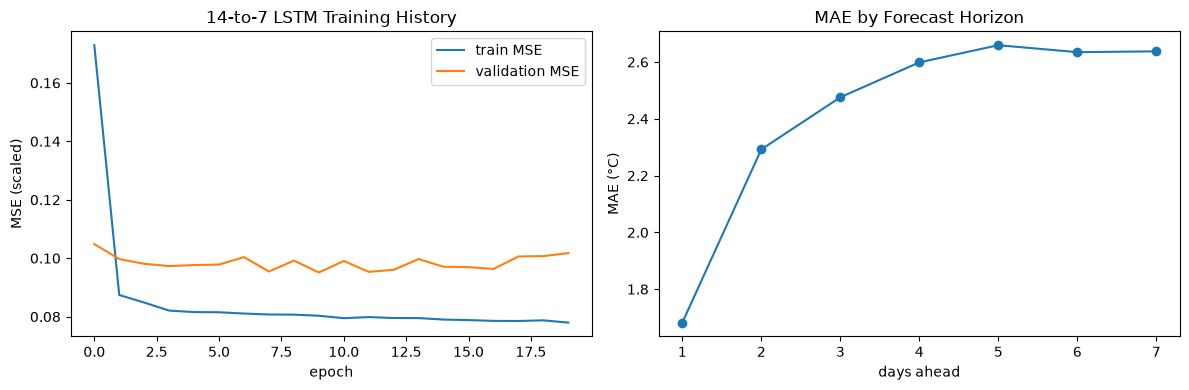

In [72]:
week_pred_scaled = predict_in_batches(week_model, Xw_test)
week_pred_temp = week_pred_scaled * train_std + train_mean
week_actual_temp = yw_test * train_std + train_mean
week_naive_temp = np.repeat(
    (Xw_test[:, -1, 0] * train_std + train_mean).reshape(-1, 1),
    forecast_days,
    axis=1
)

week_mae = np.mean(np.abs(week_pred_temp - week_actual_temp))
week_rmse = np.sqrt(np.mean((week_pred_temp - week_actual_temp) ** 2))
week_naive_mae = np.mean(np.abs(week_naive_temp - week_actual_temp))
day_mae = np.mean(np.abs(week_pred_temp - week_actual_temp), axis=0)

print(f'7-day LSTM MAE : {week_mae:.3f} °C')
print(f'7-day LSTM RMSE: {week_rmse:.3f} °C')
print(f'7-day Naive MAE: {week_naive_mae:.3f} °C')
for day, error in enumerate(day_mae, start=1):
    print(f'{day}일 후 MAE: {error:.3f} °C')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(week_train_history, label='train MSE')
axes[0].plot(week_val_history, label='validation MSE')
axes[0].set_title('14-to-7 LSTM Training History')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('MSE (scaled)')
axes[0].legend()

horizons = np.arange(1, forecast_days + 1)
axes[1].plot(horizons, day_mae, marker='o')
axes[1].set_title('MAE by Forecast Horizon')
axes[1].set_xlabel('days ahead')
axes[1].set_ylabel('MAE (°C)')
axes[1].set_xticks(horizons)
plt.tight_layout()
plt.show()

In [74]:
def predict_next_week(temperatures, last_date, model=week_model):
    if not hasattr(model, 'input_days'):
        raise RuntimeError('예전 모델이 메모리에 남아 있습니다. 커널을 다시 시작하고 전체 셀을 실행하세요.')
    input_size = model.input_days
    temperatures = np.asarray(temperatures, dtype=np.float32)
    if temperatures.shape != (input_size,):
        raise ValueError(f'최근 {input_size}일 평균기온을 정확히 {input_size}개 입력하세요.')
    if not np.all(np.isfinite(temperatures)):
        raise ValueError('기온에는 숫자만 입력하세요.')

    last_date = pd.to_datetime(last_date)
    input_dates = pd.date_range(end=last_date, periods=input_size, freq='D')
    day_of_year = input_dates.dayofyear.to_numpy()
    temp_scaled = (temperatures - train_mean) / train_std
    day_sin = np.sin(2 * np.pi * day_of_year / 365.25)
    day_cos = np.cos(2 * np.pi * day_of_year / 365.25)

    features = np.column_stack((temp_scaled, day_sin, day_cos))
    model_input = features.reshape(1, input_size, 3).astype('f')
    predicted_scaled = model.predict(model_input)[0]
    predicted_temp = predicted_scaled * train_std + train_mean
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7, freq='D')

    return pd.DataFrame({
        '날짜': future_dates,
        '예측 평균기온(°C)': np.round(predicted_temp, 1)
    })


# 사용 예시: 오래된 날짜부터 최신 날짜 순서로 최근 14일 평균기온을 입력한다.
# recent_temperatures = df[temp_col].tail(input_days).tolist()
recent_temperatures = [26.3, 24.3, 24.8, 25.8, 25.6, 26.0, 28.2, 25.1, 24.0, 26.0, 28.6, 30.3, 30.4, 28.1,]
# 마지막 입력값(28.1)이 측정된 실제 날짜로 수정하세요.
last_observed_date = pd.Timestamp('2026-07-14')
print('입력 기온:', recent_temperatures)
predict_next_week(recent_temperatures, last_observed_date)

입력 기온: [26.3, 24.3, 24.8, 25.8, 25.6, 26.0, 28.2, 25.1, 24.0, 26.0, 28.6, 30.3, 30.4, 28.1]


,날짜,예측 평균기온(°C)
0,2026-07-15,28.3
1,2026-07-16,28.2
2,2026-07-17,27.9
3,2026-07-18,28.1
4,2026-07-19,27.6
5,2026-07-20,27.8
6,2026-07-21,27.5
